# 01 · Exploratory data analysis: Sen1Floods11 (hand-labeled, Sentinel-2)

Goal: understand the data before Phase 1 training. Questions:

1. **Inventory**: chips per split and per country (flood event); file integrity.
2. **Labels**: class balance (water / land / no-data) per split and per country; chips with no water.
3. **Permanent vs flood water**: how much of the labeled water is permanent (JRC) water.
4. **Spectra**: per-band statistics on `train` vs the normalization constants TerraTorch uses.
5. **Separability**: water vs land in each band and in NDWI / MNDWI; how far a fixed threshold gets.
6. **Domain shift**: how different `bolivia` (the OOD holdout) is from `train`.
7. **Gallery**: RGB + label for example chips.

Rules respected: the **official split CSVs** are used (the `.txt` files in the same folder are the feasibility subset lists, not the splits). Nothing here selects a model; `test` and `bolivia` statistics are descriptive only and do not feed any training decision.

Data: `uv run python scripts/download_sen1floods11.py`. Figures are saved to `outputs/eda/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "sen1floods11" / "v1.1"
HAND = DATA / "data" / "flood_events" / "HandLabeled"
FIG = ROOT / "outputs" / "eda"
FIG.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "valid", "test", "bolivia"]
BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B10", "B11", "B12"]
BAND_NAMES = {  # TerraTorch names, same order as the GeoTIFF bands
    "B1": "COASTAL_AEROSOL", "B2": "BLUE", "B3": "GREEN", "B4": "RED",
    "B5": "RED_EDGE_1", "B6": "RED_EDGE_2", "B7": "RED_EDGE_3", "B8": "NIR_BROAD",
    "B8A": "NIR_NARROW", "B9": "WATER_VAPOR", "B10": "CIRRUS", "B11": "SWIR_1", "B12": "SWIR_2",
}
SCALE = 10_000  # S2Hand stores L1C reflectance x 10000 as int16

pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})

## 1. Inventory

In [2]:
rows = []
for split in SPLITS:
    csv = DATA / "splits" / "flood_handlabeled" / f"flood_{split}_data.csv"
    for line in csv.read_text().splitlines():
        if line.strip():
            chip = line.split(",")[0].removesuffix("_S1Hand.tif")
            rows.append({"chip": chip, "split": split, "country": chip.rsplit("_", 1)[0]})
chips = pd.DataFrame(rows)

assert not chips.chip.duplicated().any(), "a chip appears in more than one split"
missing = [
    (c, layer) for c in chips.chip for layer in ["S2Hand", "LabelHand", "JRCWaterHand"]
    if not (HAND / layer / f"{c}_{layer}.tif").exists()
]
print(f"{len(chips)} chips, {len(missing)} missing files")
chips.split.value_counts().reindex(SPLITS)

446 chips, 0 missing files


split
train      252
valid       89
test        90
bolivia     15
Name: count, dtype: int64

In [3]:
by_country = pd.crosstab(chips.country, chips.split).reindex(columns=SPLITS)
by_country["total"] = by_country.sum(axis=1)
by_country.sort_values("total", ascending=False)

split,train,valid,test,bolivia,total
country,,,,,
USA,41,14,14,0,69
India,40,14,14,0,68
Paraguay,39,14,14,0,67
Ghana,31,11,11,0,53
Sri-Lanka,24,9,9,0,42
Mekong,18,6,6,0,30
Spain,18,6,6,0,30
Pakistan,16,6,6,0,28
Somalia,15,5,6,0,26


Sen1Floods11 splits are random over chips **within** the 10 non-Bolivia events, so `train`, `valid` and `test` share the same events (and often neighbouring chips). Only `bolivia` is a held-out event, which is why it is the out-of-distribution test.

In [4]:
# File integrity: shape, dtype, CRS and band count on every chip.
meta = []
for c in chips.chip:
    with rasterio.open(HAND / "S2Hand" / f"{c}_S2Hand.tif") as s, \
         rasterio.open(HAND / "LabelHand" / f"{c}_LabelHand.tif") as l:
        meta.append({"chip": c, "s2_shape": (s.count, s.height, s.width), "s2_dtype": s.dtypes[0],
                     "s2_nodata": s.nodata, "lbl_shape": (l.height, l.width), "lbl_dtype": l.dtypes[0],
                     "crs": s.crs.to_string(), "res_deg": round(s.res[0], 8),
                     "lon": s.bounds.left, "lat": s.bounds.top})
meta = pd.DataFrame(meta)
for col in ["s2_shape", "s2_dtype", "s2_nodata", "lbl_shape", "lbl_dtype", "crs", "res_deg"]:
    print(f"{col:10s}", meta[col].value_counts().to_dict())
chips = chips.merge(meta[["chip", "lon", "lat"]], on="chip")

s2_shape   {(13, 512, 512): 446}
s2_dtype   {'int16': 446}
s2_nodata  {0.0: 446}
lbl_shape  {(512, 512): 446}
lbl_dtype  {'int16': 446}
crs        {'EPSG:4326': 446}
res_deg    {8.983e-05: 446}


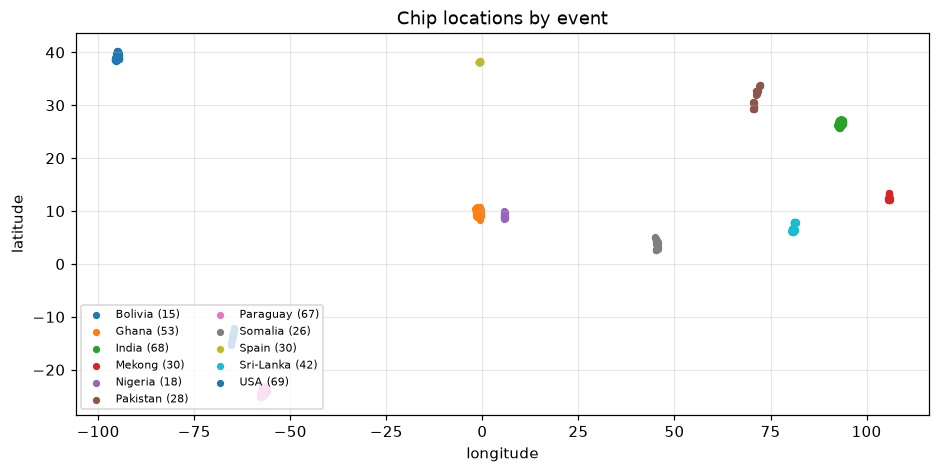

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for country, g in chips.groupby("country"):
    ax.scatter(g.lon, g.lat, s=14, label=f"{country} ({len(g)})")
ax.set(xlabel="longitude", ylabel="latitude", title="Chip locations by event")
ax.legend(fontsize=7, ncol=2, loc="lower left")
ax.grid(alpha=0.3)
fig.savefig(FIG / "chip_locations.png")

## 2. One pass over every chip

A single streaming pass collects everything below so the 446 chips (≈ 3 GB as int16) never sit in memory together.

Valid pixel = label ≠ −1 **and** S2 not no-data (all bands 0). Label values: `1` water, `0` not water, `−1` no data / not valid.

In [6]:
HIST_EDGES = np.arange(0, 10_001, 50)        # reflectance x 1e4, per band
IDX_EDGES = np.linspace(-1, 1, 201)          # NDWI / MNDWI
B = {b: i for i, b in enumerate(BANDS)}


def ratio(a, b):
    a, b = a.astype(np.float32), b.astype(np.float32)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(a + b > 0, (a - b) / (a + b), 0)


# per split x class (0 land, 1 water) accumulators
band_hist = {(s, k): np.zeros((len(BANDS), len(HIST_EDGES) - 1), np.int64) for s in SPLITS for k in (0, 1)}
ndwi_hist = {(s, k): np.zeros(len(IDX_EDGES) - 1, np.int64) for s in SPLITS for k in (0, 1)}
mndwi_hist = {(s, k): np.zeros(len(IDX_EDGES) - 1, np.int64) for s in SPLITS for k in (0, 1)}
band_sum = {(s, k): np.zeros(len(BANDS)) for s in SPLITS for k in (0, 1)}
band_sq = {(s, k): np.zeros(len(BANDS)) for s in SPLITS for k in (0, 1)}

per_chip = []
for c, split in zip(chips.chip, chips.split):
    with rasterio.open(HAND / "S2Hand" / f"{c}_S2Hand.tif") as r:
        x = r.read()
    with rasterio.open(HAND / "LabelHand" / f"{c}_LabelHand.tif") as r:
        y = r.read(1)
    with rasterio.open(HAND / "JRCWaterHand" / f"{c}_JRCWaterHand.tif") as r:
        jrc = r.read(1)

    s2_nodata = (x == 0).all(axis=0)
    valid = (y != -1) & ~s2_nodata
    ndwi, mndwi = ratio(x[B["B3"]], x[B["B8"]]), ratio(x[B["B3"]], x[B["B11"]])

    rec = {"chip": c, "n_px": y.size, "label_nodata": int((y == -1).sum()),
           "s2_nodata": int(s2_nodata.sum()), "valid": int(valid.sum()),
           "water": int((valid & (y == 1)).sum()), "land": int((valid & (y == 0)).sum()),
           "jrc_perm": int((valid & (jrc == 1)).sum()),
           "water_and_jrc": int((valid & (y == 1) & (jrc == 1)).sum()),
           # crude brightness proxy for residual cloud / haze in valid pixels (blue > 0.2)
           "bright_blue": int((valid & (x[B["B2"]] > 2000)).sum()),
           "cirrus_mean": float(x[B["B10"]][valid].mean()) if valid.any() else np.nan}
    for b in BANDS:
        rec[f"mean_{b}"] = float(x[B[b]][valid].mean()) if valid.any() else np.nan
    per_chip.append(rec)

    for k in (0, 1):
        m = valid & (y == k)
        if not m.any():
            continue
        px = x[:, m].astype(np.float64)                     # (13, n)
        band_sum[split, k] += px.sum(axis=1)
        band_sq[split, k] += (px ** 2).sum(axis=1)
        for i in range(len(BANDS)):
            band_hist[split, k][i] += np.histogram(px[i], HIST_EDGES)[0]
        ndwi_hist[split, k] += np.histogram(ndwi[m], IDX_EDGES)[0]
        mndwi_hist[split, k] += np.histogram(mndwi[m], IDX_EDGES)[0]

per_chip = chips.merge(pd.DataFrame(per_chip), on="chip")
per_chip["water_frac"] = per_chip.water / per_chip.valid.where(per_chip.valid > 0)
per_chip["invalid_frac"] = 1 - per_chip.valid / per_chip.n_px
print("pixel conservation check:", (per_chip.water + per_chip.land == per_chip.valid).all())

pixel conservation check: True


## 3. Label statistics

In [7]:
def balance(g):
    tot = g[["water", "land", "valid", "n_px"]].sum()
    return pd.Series({
        "chips": len(g),
        "water_%_of_valid": 100 * tot.water / tot.valid,
        "invalid_%_of_all": 100 * (1 - tot.valid / tot.n_px),
        "chips_without_water": int((g.water == 0).sum()),
        "median_chip_water_%": 100 * g.water_frac.median(),
    })

split_balance = per_chip.groupby("split").apply(balance, include_groups=False).reindex(SPLITS)
split_balance

,chips,water_%_of_valid,invalid_%_of_all,chips_without_water,median_chip_water_%
split,,,,,
train,252.0,9.5072,13.2715,33.0,2.4872
valid,89.0,11.0255,13.0133,12.0,2.5484
test,90.0,12.2931,13.2481,8.0,2.4275
bolivia,15.0,15.8593,27.0701,0.0,6.2708


In [8]:
country_balance = (per_chip.groupby("country").apply(balance, include_groups=False)
                   .sort_values("water_%_of_valid", ascending=False))
country_balance

,chips,water_%_of_valid,invalid_%_of_all,chips_without_water,median_chip_water_%
country,,,,,
Mekong,30.0,24.1220,9.3223,1.0,7.6120
Nigeria,18.0,23.4552,14.3146,0.0,2.3717
Bolivia,15.0,15.8593,27.0701,0.0,6.2708
Spain,30.0,13.1538,1.7359,0.0,3.4008
India,68.0,12.3927,16.0003,2.0,5.9023
Sri-Lanka,42.0,11.7975,9.5076,2.0,2.9956
Paraguay,67.0,8.1130,5.3211,11.0,2.0384
Pakistan,28.0,7.4974,26.7497,7.0,1.2501
Somalia,26.0,6.5087,21.1326,4.0,2.2581


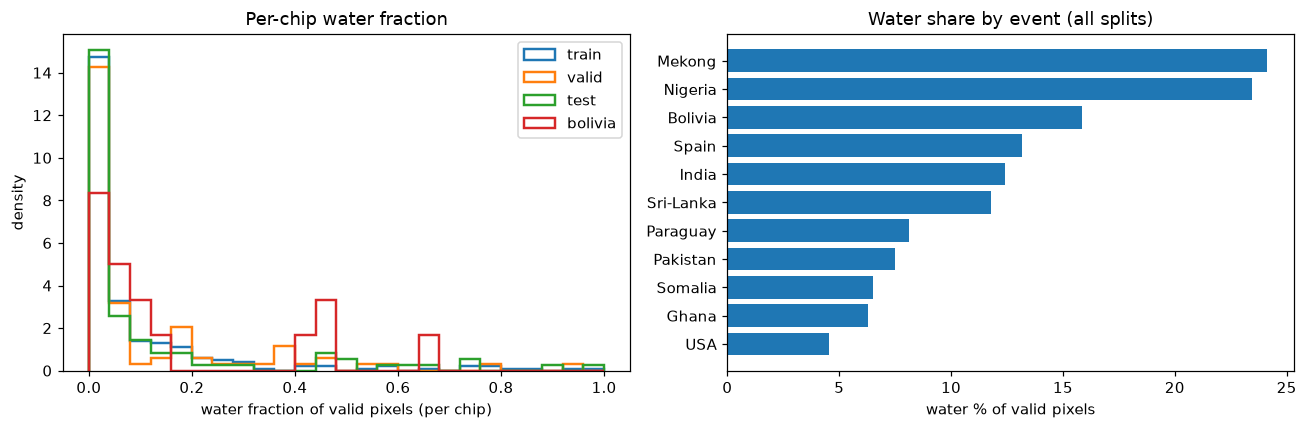

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1, 26)
for s in SPLITS:
    axes[0].hist(per_chip.loc[per_chip.split == s, "water_frac"].dropna(), bins=bins,
                 histtype="step", lw=1.6, density=True, label=s)
axes[0].set(xlabel="water fraction of valid pixels (per chip)", ylabel="density",
            title="Per-chip water fraction")
axes[0].legend()

order = country_balance.index
axes[1].barh(order, country_balance["water_%_of_valid"], color="tab:blue")
axes[1].set(xlabel="water % of valid pixels", title="Water share by event (all splits)")
axes[1].invert_yaxis()
fig.tight_layout()
fig.savefig(FIG / "label_balance.png")

count    446.0000
mean       0.1368
std        0.2241
min        0.0000
50%        0.0095
90%        0.4142
99%        1.0000
max        1.0000
Name: invalid_frac, dtype: float64

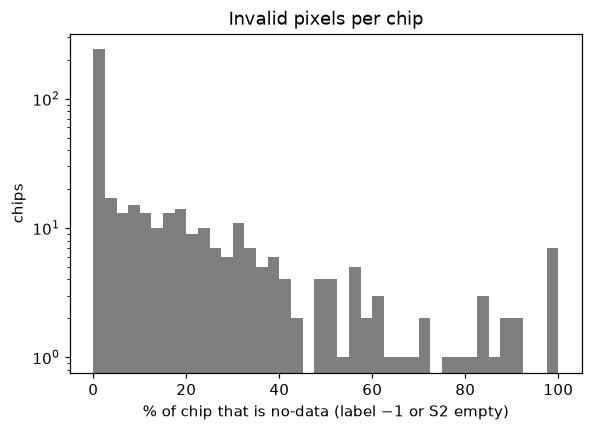

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(100 * per_chip.invalid_frac, bins=40, color="tab:gray")
ax.set(xlabel="% of chip that is no-data (label −1 or S2 empty)", ylabel="chips",
       title="Invalid pixels per chip")
ax.set_yscale("log")
fig.savefig(FIG / "invalid_fraction.png")
per_chip.invalid_frac.describe(percentiles=[.5, .9, .99])

## 4. Permanent vs flood water (JRC)

In [11]:
jrc = per_chip.groupby("split")[["water", "jrc_perm", "water_and_jrc"]].sum().reindex(SPLITS)
jrc["%_of_water_that_is_permanent"] = 100 * jrc.water_and_jrc / jrc.water
jrc["%_of_permanent_labeled_water"] = 100 * jrc.water_and_jrc / jrc.jrc_perm
jrc

,water,jrc_perm,water_and_jrc,%_of_water_that_is_permanent,%_of_permanent_labeled_water
split,,,,,
train,5446993,1556825,1521790,27.9382,97.7496
valid,2237593,635749,611052,27.3085,96.1153
test,2516071,943131,899398,35.7461,95.3630
bolivia,454800,38836,29951,6.5855,77.1217


If a large share of labeled water is permanent, a model can score well by finding rivers and lakes rather than **flood** water. This matters for interpreting IoU and for the Peru test set (where the target is flooded land).

## 5. Band statistics on `train` vs the TerraTorch constants

In [12]:
from terratorch.datamodules.sen1floods11 import MEANS, STDS

n = {s: {k: band_hist[s, k].sum(axis=1)[0] for k in (0, 1)} for s in SPLITS}
s_sum = {s: band_sum[s, 0] + band_sum[s, 1] for s in SPLITS}
s_sq = {s: band_sq[s, 0] + band_sq[s, 1] for s in SPLITS}
s_n = {s: n[s][0] + n[s][1] for s in SPLITS}

def mean_std(s):
    mu = s_sum[s] / s_n[s]
    return mu / SCALE, np.sqrt(s_sq[s] / s_n[s] - mu ** 2) / SCALE

mu, sd = mean_std("train")
norm = pd.DataFrame({
    "band": BANDS,
    "train_mean": mu, "terratorch_mean": [MEANS[BAND_NAMES[b]] for b in BANDS],
    "train_std": sd, "terratorch_std": [STDS[BAND_NAMES[b]] for b in BANDS],
}).set_index("band")
norm["mean_diff_in_std"] = (norm.train_mean - norm.terratorch_mean) / norm.terratorch_std
norm

/Users/gersongarrido/Projects/peru-flood-segmentation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/gersongarrido/Projects/peru-flood-segmentation/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


,train_mean,terratorch_mean,train_std,terratorch_std,mean_diff_in_std
band,,,,,
B1,0.1500,0.1645,0.0328,0.0698,-0.2075
B2,0.1253,0.1413,0.0352,0.0741,-0.2155
B3,0.1228,0.1380,0.0374,0.0737,-0.2063
B4,0.1062,0.1235,0.0532,0.0869,-0.1995
B5,0.1336,0.1481,0.0452,0.0778,-0.1871
B6,0.2299,0.2399,0.0686,0.0911,-0.1103
B7,0.2770,0.2859,0.0882,0.1069,-0.0828
B8,0.2558,0.2635,0.0851,0.1010,-0.0756
B8A,0.3008,0.3090,0.1010,0.1180,-0.0701


`train` statistics here use **valid pixels only** (label ≠ −1). TerraTorch's constants may have been computed over all pixels or a different subset, so small differences are expected; large ones (|diff| ≳ 0.2 std) would be worth a note in the method chapter. TerraMind and Prithvi have their **own** pretraining normalization, which is what fine-tuning should match.

In [13]:
def pct(hist, q):
    c = np.cumsum(hist) / hist.sum()
    return HIST_EDGES[1:][np.searchsorted(c, q)]

rows = []
for s in SPLITS:
    h = band_hist[s, 0] + band_hist[s, 1]
    for i, b in enumerate(BANDS):
        rows.append({"split": s, "band": b, "p1": pct(h[i], .01), "p50": pct(h[i], .5),
                     "p99": pct(h[i], .99), "sat_%": 100 * h[i, -1] / h[i].sum()})
pctl = pd.DataFrame(rows).pivot(index="band", columns="split", values=["p1", "p50", "p99"]).reindex(BANDS)
pctl  # reflectance x 1e4; last histogram bin is 9950–10000+ only if values reach it

p1                       p50                       p99              \
split bolivia  test train valid bolivia  test train valid bolivia  test train   
band                                                                            
B1       1150  1100  1150  1150    1250  1400  1450  1450    2500  2450  2650   
B2        800   850   850   850     950  1150  1150  1150    2250  2250  2400   
B3        550   750   750   700     850  1100  1150  1150    2150  2300  2350   
B4        350   400   450   400     500   850   950   900    2050  2650  2700   
B5        300   550   600   600     900  1200  1250  1250    2150  2700  2750   
B6        250   500   600   550    2050  2400  2400  2350    3450  3700  3800   
B7        250   550   650   600    2550  2850  2900  2800    4500  4600  4700   
B8        200   450   550   500    2350  2650  2700  2600    4200  4300  4350   
B8A       200   450   550   500    2800  3150  3150  3100    4950  5050  5100   
B9         50   100   100   100     250   400   400   400     450  1200  1400   
B10        50    50    50    50      50    50    50    50      50   650   900   
B11        50   100   200   150    1450  1900  1950  1950    3000  4200  4050   
B12        50   100   150   100     600   900   950   950    1950  2950  2900   

             
split valid  
band         
B1     2500  
B2     2300  
B3     2300  
B4     2550  
B5     2550  
B6     3550  
B7     4450  
B8     4200  
B8A    4900  
B9     1200  
B10     700  
B11    3950  
B12    2800

## 6. Water vs land separability

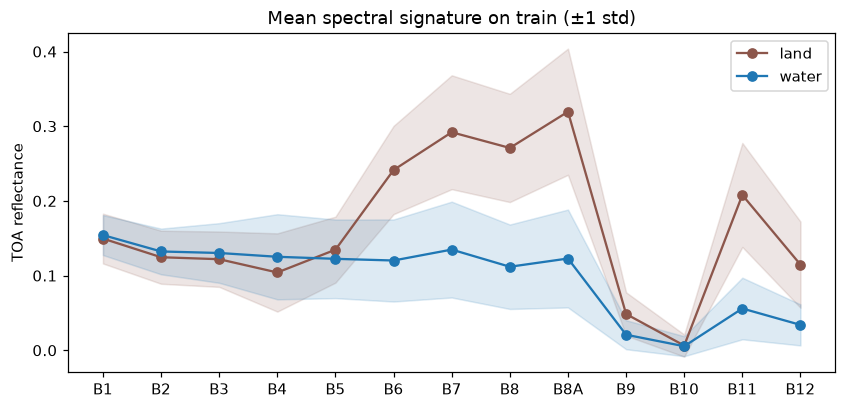

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(BANDS))
for k, name, col in [(0, "land", "tab:brown"), (1, "water", "tab:blue")]:
    m = band_sum["train", k] / n["train"][k] / SCALE
    s = np.sqrt(band_sq["train", k] / n["train"][k] - (band_sum["train", k] / n["train"][k]) ** 2) / SCALE
    ax.plot(xs, m, "o-", color=col, label=name)
    ax.fill_between(xs, m - s, m + s, color=col, alpha=0.15)
ax.set_xticks(xs, BANDS)
ax.set(ylabel="TOA reflectance", title="Mean spectral signature on train (±1 std)")
ax.legend()
fig.savefig(FIG / "spectral_signature.png")

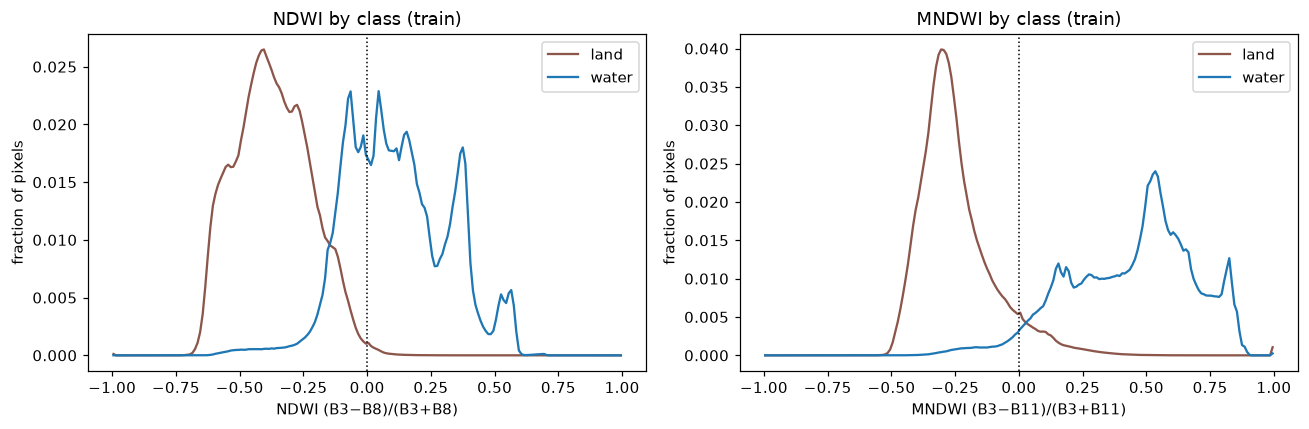

In [15]:
centers = (IDX_EDGES[:-1] + IDX_EDGES[1:]) / 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], ndwi_hist, "NDWI (B3−B8)/(B3+B8)"), (axes[1], mndwi_hist, "MNDWI (B3−B11)/(B3+B11)")]:
    for k, lab, col in [(0, "land", "tab:brown"), (1, "water", "tab:blue")]:
        h = hist["train", k]
        ax.plot(centers, h / h.sum(), color=col, label=lab)
    ax.axvline(0, color="k", ls=":", lw=1)
    ax.set(xlabel=name, ylabel="fraction of pixels", title=f"{name.split()[0]} by class (train)")
    ax.legend()
fig.tight_layout()
fig.savefig(FIG / "index_separability.png")

In [16]:
def threshold_scores(hist, t):
    """IoU / F1 of the rule `index > t` for water, from class histograms."""
    above = centers > t
    tp, fn = hist[1][above].sum(), hist[1][~above].sum()
    fp = hist[0][above].sum()
    return tp / (tp + fp + fn), 2 * tp / (2 * tp + fp + fn)

thresholds = np.round(np.arange(-0.5, 0.51, 0.05), 2)
best = {}
for idx_name, hist in [("NDWI", ndwi_hist), ("MNDWI", mndwi_hist)]:
    tr = {k: hist["train", k] for k in (0, 1)}
    best[idx_name] = max(thresholds, key=lambda t: threshold_scores(tr, t)[0])

rows = []
for idx_name, hist in [("NDWI", ndwi_hist), ("MNDWI", mndwi_hist)]:
    for t, how in [(0.0, "fixed 0"), (best[idx_name], "tuned on train")]:
        for s in SPLITS:
            iou, f1 = threshold_scores({k: hist[s, k] for k in (0, 1)}, t)
            rows.append({"index": idx_name, "threshold": f"{t:+.2f} ({how})", "split": s, "IoU": iou, "F1": f1})
thr = pd.DataFrame(rows).pivot(index=["index", "threshold"], columns="split", values="IoU")[SPLITS]
thr  # water IoU, pixel-pooled over the split

split                          train   valid    test  bolivia
index threshold                                              
MNDWI +0.00 (fixed 0)         0.5712  0.5976  0.6583   0.5499
      +0.15 (tuned on train)  0.7264  0.7446  0.7867   0.7026
NDWI  +0.00 (fixed 0)         0.6506  0.6723  0.7720   0.8317
      -0.05 (tuned on train)  0.6870  0.7103  0.7721   0.8157

This is a **non-learned reference**, not a reported baseline: thresholds are binned at 0.01 and tuned on `train` only. It shows how much of the task is solvable from one spectral index, and how much of the drop on `bolivia` is spectral shift that any model has to absorb.

## 7. Domain shift: `bolivia` vs the other events

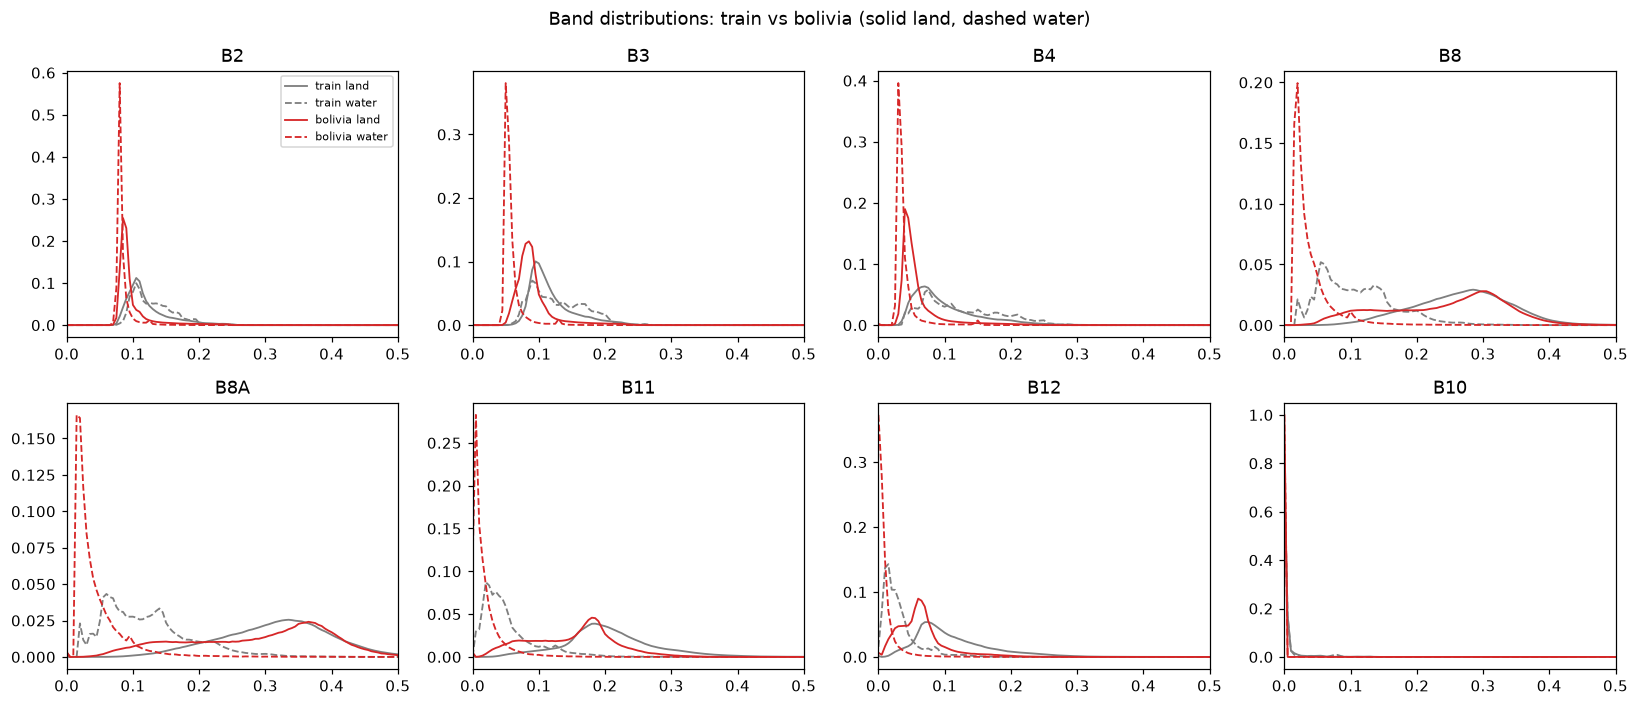

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharey=False)
for ax, b in zip(axes.flat, ["B2", "B3", "B4", "B8", "B8A", "B11", "B12", "B10"]):
    i = B[b]
    for s, col in [("train", "tab:gray"), ("bolivia", "tab:red")]:
        for k, ls in [(0, "-"), (1, "--")]:
            h = band_hist[s, k][i]
            ax.plot(HIST_EDGES[:-1] / SCALE, h / h.sum(), color=col, ls=ls, lw=1.2,
                    label=f"{s} {'water' if k else 'land'}")
    ax.set(title=b, xlim=(0, 0.5))
axes[0, 0].legend(fontsize=7)
fig.suptitle("Band distributions: train vs bolivia (solid land, dashed water)")
fig.tight_layout()
fig.savefig(FIG / "bolivia_shift_bands.png")

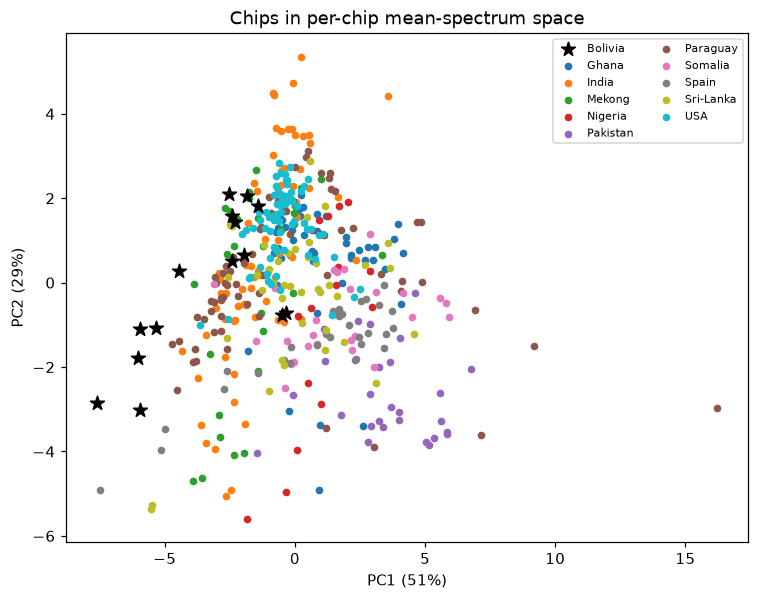

In [18]:
from sklearn.decomposition import PCA

feat_cols = [f"mean_{b}" for b in BANDS]
f = per_chip.dropna(subset=feat_cols)
z = (f[feat_cols] - f[feat_cols].mean()) / f[feat_cols].std()
pc = PCA(2).fit(z)
xy = pc.transform(z)

fig, ax = plt.subplots(figsize=(8, 6))
for country in sorted(f.country.unique()):
    m = (f.country == country).values
    style = dict(s=90, marker="*", color="black", zorder=3) if country == "Bolivia" else dict(s=16)
    ax.scatter(xy[m, 0], xy[m, 1], label=country, **style)
ax.set(xlabel=f"PC1 ({pc.explained_variance_ratio_[0]:.0%})", ylabel=f"PC2 ({pc.explained_variance_ratio_[1]:.0%})",
       title="Chips in per-chip mean-spectrum space")
ax.legend(fontsize=7, ncol=2)
fig.savefig(FIG / "chip_pca.png")

In [19]:
# Residual cloud / haze proxy within valid pixels.
q = per_chip.assign(bright_blue_pct=100 * per_chip.bright_blue / per_chip.valid,
                    cirrus_mean=per_chip.cirrus_mean / SCALE)
q.groupby("split")[["bright_blue_pct", "cirrus_mean"]].describe().T.reindex(columns=SPLITS)

split                     train    valid     test     bolivia
bright_blue_pct count  251.0000  86.0000  88.0000  1.5000e+01
                mean     4.6303   4.2322   4.6123  2.2079e+00
                std     13.3291  13.4453  12.5676  3.4387e+00
                min      0.0000   0.0000   0.0000  5.5098e-03
                25%      0.0180   0.0101   0.0215  4.0989e-02
                50%      0.3558   0.2811   0.3062  3.9145e-01
                75%      3.8994   3.1368   2.7015  2.7203e+00
                max     95.2187  90.2591  71.0903  1.0591e+01
cirrus_mean     count  251.0000  86.0000  88.0000  1.5000e+01
                mean     0.0061   0.0056   0.0050  8.4699e-04
                std      0.0137   0.0110   0.0096  9.9436e-05
                min      0.0006   0.0006   0.0006  6.9214e-04
                25%      0.0012   0.0011   0.0010  7.8799e-04
                50%      0.0029   0.0018   0.0019  8.1824e-04
                75%      0.0053   0.0060   0.0050  9.3485e-04
                max      0.1175   0.0681   0.0720  1.0241e-03

## 8. Gallery

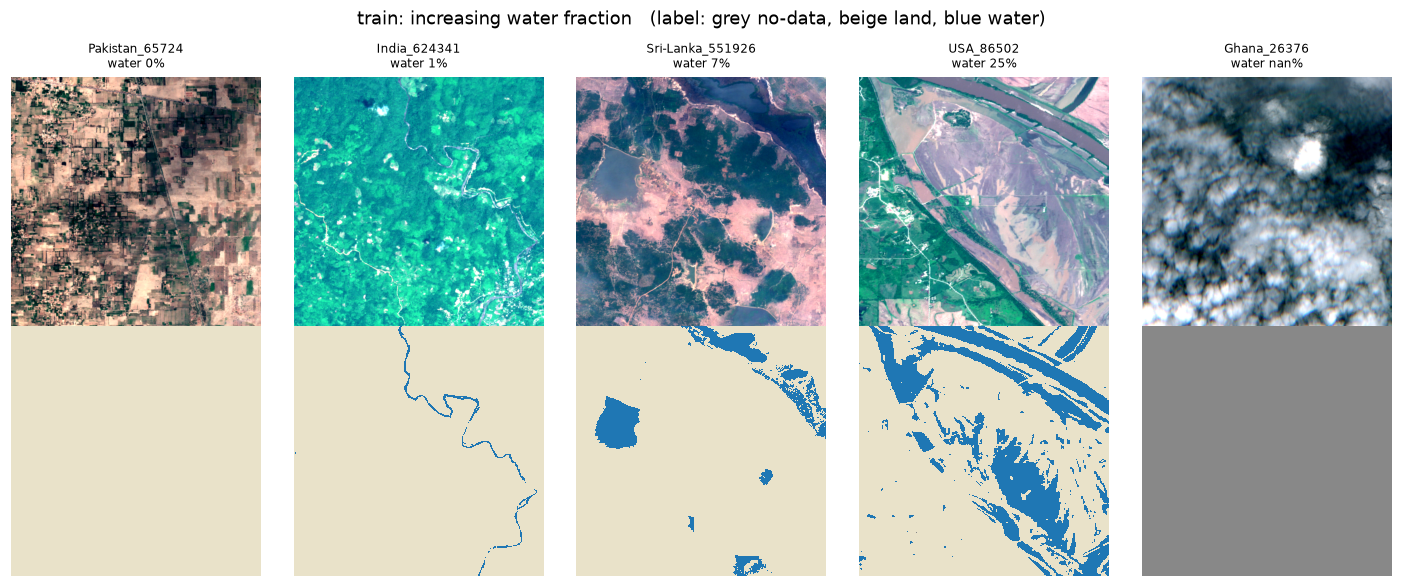

In [20]:
def rgb(x):
    img = np.stack([x[B["B4"]], x[B["B3"]], x[B["B2"]]], -1).astype(np.float32) / SCALE
    lo, hi = np.percentile(img[img > 0], [2, 98]) if (img > 0).any() else (0, 1)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

LABEL_CMAP = plt.matplotlib.colors.ListedColormap(["#888888", "#e9e2c9", "#1f77b4"])

def show(chip_ids, title, fname):
    fig, axes = plt.subplots(2, len(chip_ids), figsize=(2.6 * len(chip_ids), 5.4))
    for j, c in enumerate(chip_ids):
        with rasterio.open(HAND / "S2Hand" / f"{c}_S2Hand.tif") as r:
            x = r.read()
        with rasterio.open(HAND / "LabelHand" / f"{c}_LabelHand.tif") as r:
            y = r.read(1)
        wf = per_chip.set_index("chip").water_frac[c]
        axes[0, j].imshow(rgb(x))
        axes[0, j].set_title(f"{c}\nwater {wf:.0%}", fontsize=8)
        axes[1, j].imshow(y, cmap=LABEL_CMAP, vmin=-1, vmax=1, interpolation="nearest")
        for a in axes[:, j]:
            a.axis("off")
    fig.suptitle(f"{title}   (label: grey no-data, beige land, blue water)")
    fig.tight_layout()
    fig.savefig(FIG / fname)

rng = np.random.default_rng(0)
train_q = per_chip[per_chip.split == "train"].sort_values("water_frac")
picks = [train_q.iloc[int(p * (len(train_q) - 1))].chip for p in (0.1, 0.4, 0.7, 0.9, 1.0)]
show(picks, "train: increasing water fraction", "gallery_train.png")

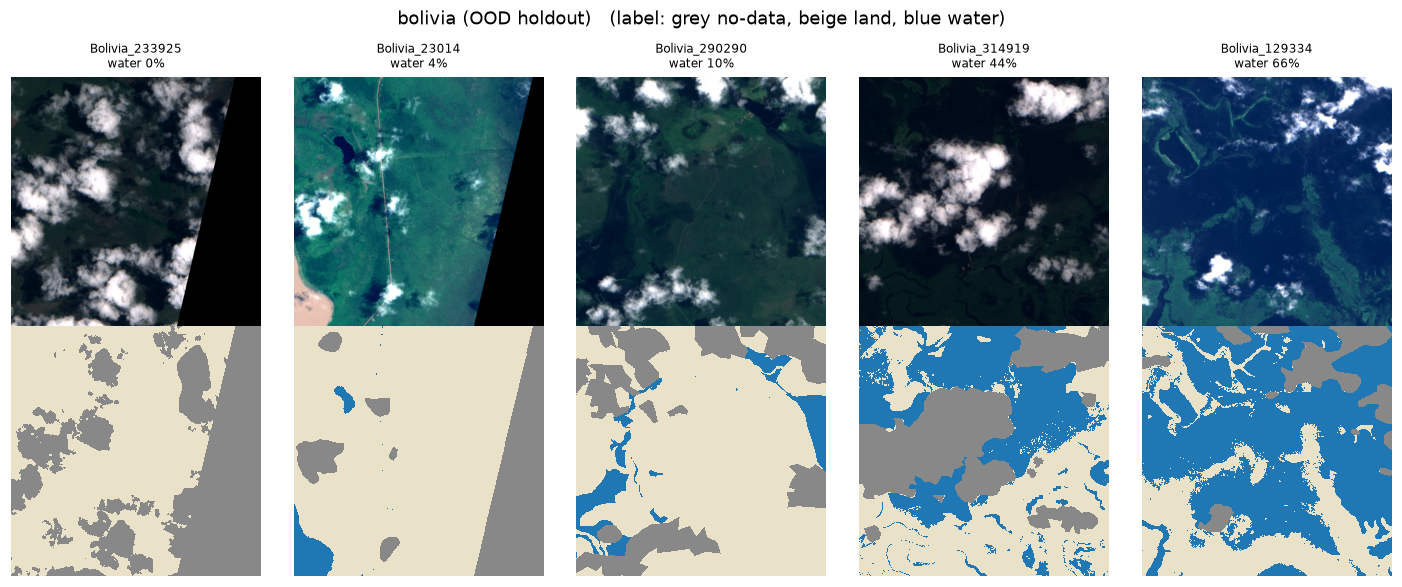

In [21]:
show(list(per_chip[per_chip.split == "bolivia"].sort_values("water_frac").chip.iloc[[0, 4, 8, 12, 14]]),
     "bolivia (OOD holdout)", "gallery_bolivia.png")

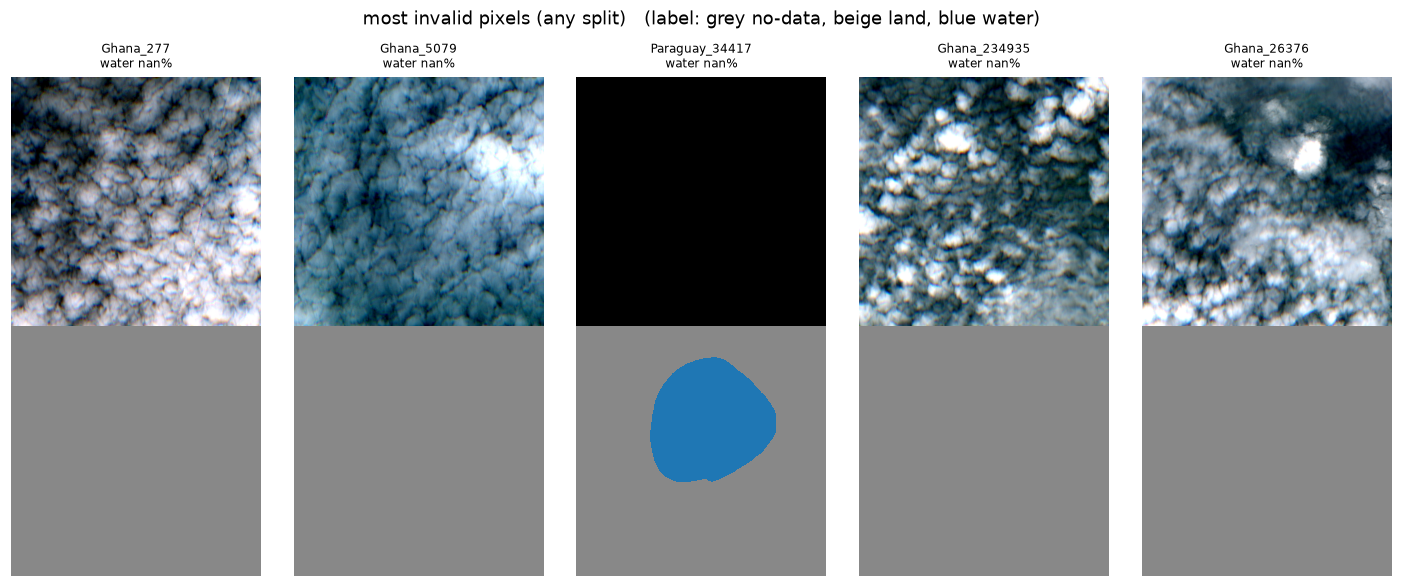

In [22]:
show(list(per_chip.sort_values("invalid_frac", ascending=False).chip.head(5)),
     "most invalid pixels (any split)", "gallery_invalid.png")

## 9. Findings

Numbers below are from the run committed with this notebook (pixel-pooled unless stated; "valid" = label ≠ −1).

1. **Data is complete and uniform.** 446 chips (252 / 89 / 90 / 15), no missing files, all 13×512×512 int16, EPSG:4326 at ~10 m. 6 chips are entirely invalid (0 valid pixels); they contribute nothing to the loss and should not break the metric code.
2. **Strong class imbalance.** Water is 9.5 % of valid pixels in `train` (11.0 % valid, 12.3 % test, 15.9 % bolivia). The median chip is only ~2.5 % water and 33 train chips have no water at all. → Use a loss that copes with imbalance (e.g. weighted CE or CE + Dice) and report **water IoU**, not pixel accuracy.
3. **Events differ a lot.** Water share ranges from 4.6 % (USA) to 24.1 % (Mekong); Ghana has 33.9 % invalid pixels and 26 of its 53 chips have no water. A pooled score hides this, so report per-event IoU in the error analysis.
4. **`train` / `valid` / `test` share the same 10 events**, so `test` is *in-distribution*. Only `bolivia` is a held-out event. This supports making Bolivia (and Peru) the main generalization evidence.
5. **Bolivia is cloudier and wetter.** 27.1 % of Bolivia pixels are invalid (clouds masked as −1, see gallery) vs ~13 % elsewhere, and its median chip is 6.3 % water vs ~2.5 %. In spectral space Bolivia sits at the dark/low-PC1 edge of the training cloud (PCA plot), and its visible/SWIR percentiles are lower than `train`'s.
6. **~28 % of labeled water in train/valid is permanent (JRC)** (35.7 % in test, only 6.6 % in Bolivia). Nearly all permanent water is labeled water (≥ 95 %). A model is partly rewarded for finding rivers and lakes; Bolivia is mostly *flood* water. Consider also reporting IoU on non-permanent water.
7. **A single index already gets far.** NDWI > −0.05 (tuned on train) gives water IoU 0.71 on valid and 0.82 on Bolivia; MNDWI > 0.15 gives 0.74 / 0.70. Learned models need to clearly beat this non-learned reference, especially on Bolivia, for the foundation-model story to hold.
8. **Normalization.** On valid train pixels, the visible bands are ~0.2 std darker than the TerraTorch Sen1Floods11 constants, and our per-band std is roughly half of theirs for B1–B5. Their constants were probably computed over different pixels. This does not matter for TerraMind/Prithvi as long as each uses its **own pretraining** normalization (CLAUDE.md rule), but it does matter for the U-Net baseline: compute its constants from `train` (this notebook) and state that in the method chapter.
9. **Residual cloud/haze inside valid pixels is small but uneven** (median 0.3 % of valid pixels with blue > 0.2, max 95 % in one train chip). The −1 mask removes most clouds, so Sen1Floods11 is close to cloud-free by construction, unlike real flood scenes.

In [23]:
per_chip.to_csv(FIG / "per_chip_stats.csv", index=False)
print(split_balance.round(2).to_string())
print()
print(jrc.round(1).to_string())
print()
print(thr.round(3).to_string())
print()
print(norm[["mean_diff_in_std"]].round(2).T.to_string())

         chips  water_%_of_valid  invalid_%_of_all  chips_without_water  median_chip_water_%
split                                                                                       
train    252.0              9.51             13.27                 33.0                 2.49
valid     89.0             11.03             13.01                 12.0                 2.55
test      90.0             12.29             13.25                  8.0                 2.43
bolivia   15.0             15.86             27.07                  0.0                 6.27

           water  jrc_perm  water_and_jrc  %_of_water_that_is_permanent  %_of_permanent_labeled_water
split                                                                                                
train    5446993   1556825        1521790                          27.9                          97.7
valid    2237593    635749         611052                          27.3                          96.1
test     2516071    943131       